# Notebook 03 — Modelos Predictivos

**Proyecto:** Impacto de la IA generativa en estudiantes universitarios  
**Fase:** 3 de 3  
**Objetivo:** Entrenar y evaluar modelos de regresión para predecir el cambio en GPA y modelos de clasificación para predecir el riesgo académico, a partir de los patrones de uso de IA generativa identificados en las fases anteriores.

## 1. Librerías y configuración

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100
np.random.seed(42)

## 2. Carga y preparación de datos

In [2]:
df = pd.read_csv('../data/processed/students_model_ready.csv')
print('Dataset cargado:', df.shape)
df.head(3)

Dataset cargado: (50000, 26)


,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,...,Cambio_GPA,Nivel_Uso_IA,Dependencia_Alta,Estudio_Total,Riesgo_Academico,Year_Encoded,Prompt_Skill_Encoded,Policy_Encoded,Burnout_Encoded,Uso_IA_Encoded
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,1,8.13,...,-0.025,Alto,0,31.44,1,4,1,1,2,2
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,0,16.65,...,-0.125,Bajo,0,17.77,0,3,3,1,0,0
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,0,10.35,...,0.101,Alto,0,31.61,0,1,1,0,1,2


In [3]:
# One-hot encoding para variables categóricas nominales
df_model = pd.get_dummies(
    df,
    columns=['Major_Category', 'Primary_Use_Case', 'Institutional_Policy',
             'Year_of_Study', 'Prompt_Engineering_Skill', 'Nivel_Uso_IA'],
    drop_first=True
)

# Eliminar columnas no útiles para el modelado
cols_drop = ['Student_ID', 'Burnout_Risk_Level', 'Burnout_Encoded']
df_model.drop(columns=[c for c in cols_drop if c in df_model.columns], inplace=True)

print('Columnas para modelado:', df_model.shape[1])

Columnas para modelado: 35


Se aplicó one-hot encoding a las variables categóricas nominales eliminando la primera categoría en cada grupo para evitar multicolinealidad perfecta. Las variables con encoding ordinal ya aplicado en el ETL (Year_Encoded, Prompt_Skill_Encoded, Policy_Encoded) se mantienen tal cual. Se eliminaron Student_ID (identificador sin valor predictivo) y las versiones de Burnout ya codificadas para evitar redundancia.

---
## Parte 1 — Regresión: predicción del cambio en GPA

**Variable objetivo:** `Cambio_GPA` (continua)  
Queremos predecir si un estudiante mejorará o empeorará su rendimiento académico durante el semestre, a partir de su perfil de uso de IA y características académicas previas.

### 3. Preparación del conjunto para regresión

In [4]:
target_reg = 'Cambio_GPA'

# Excluir variables que son consecuencia directa del target
cols_excluir_reg = [target_reg, 'Post_Semester_GPA', 'Riesgo_Academico', 'Dependencia_Alta', 'Uso_IA_Encoded']
X_reg = df_model.drop(columns=[c for c in cols_excluir_reg if c in df_model.columns])
y_reg = df_model[target_reg]

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

print('Entrenamiento:', X_train_r.shape)
print('Prueba:       ', X_test_r.shape)
print('Media Cambio_GPA en entrenamiento:', y_train_r.mean().round(4))

Entrenamiento: (40000, 30)
Prueba:        (10000, 30)
Media Cambio_GPA en entrenamiento: 0.2026


### 4. Modelos de regresión

In [5]:
# Modelo 1: Regresión Lineal
lr = LinearRegression()
lr.fit(X_train_r, y_train_r)
pred_lr = lr.predict(X_test_r)

rmse_lr = np.sqrt(mean_squared_error(y_test_r, pred_lr))
mae_lr  = mean_absolute_error(y_test_r, pred_lr)
r2_lr   = r2_score(y_test_r, pred_lr)
print(f'Regresión Lineal  | RMSE: {rmse_lr:.4f} | MAE: {mae_lr:.4f} | R²: {r2_lr:.4f}')

Regresión Lineal  | RMSE: 0.1565 | MAE: 0.1231 | R²: 0.2870


In [6]:
# Modelo 2: Árbol de Decisión
dt_reg = DecisionTreeRegressor(max_depth=6, random_state=42)
dt_reg.fit(X_train_r, y_train_r)
pred_dt_r = dt_reg.predict(X_test_r)

rmse_dt = np.sqrt(mean_squared_error(y_test_r, pred_dt_r))
mae_dt  = mean_absolute_error(y_test_r, pred_dt_r)
r2_dt   = r2_score(y_test_r, pred_dt_r)
print(f'Árbol de Decisión | RMSE: {rmse_dt:.4f} | MAE: {mae_dt:.4f} | R²: {r2_dt:.4f}')

Árbol de Decisión | RMSE: 0.1530 | MAE: 0.1193 | R²: 0.3187


In [7]:
# Modelo 3: Random Forest
rf_reg = RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42, n_jobs=-1)
rf_reg.fit(X_train_r, y_train_r)
pred_rf_r = rf_reg.predict(X_test_r)

rmse_rf = np.sqrt(mean_squared_error(y_test_r, pred_rf_r))
mae_rf  = mean_absolute_error(y_test_r, pred_rf_r)
r2_rf   = r2_score(y_test_r, pred_rf_r)
print(f'Random Forest     | RMSE: {rmse_rf:.4f} | MAE: {mae_rf:.4f} | R²: {r2_rf:.4f}')

Random Forest     | RMSE: 0.1440 | MAE: 0.1132 | R²: 0.3967


### 5. Comparación de modelos de regresión

In [8]:
resultados_reg = pd.DataFrame({
    'Modelo': ['Regresión Lineal', 'Árbol de Decisión', 'Random Forest'],
    'RMSE': [rmse_lr, rmse_dt, rmse_rf],
    'MAE':  [mae_lr,  mae_dt,  mae_rf],
    'R²':   [r2_lr,   r2_dt,   r2_rf]
}).round(4)
resultados_reg

,Modelo,RMSE,MAE,R²
0,Regresión Lineal,0.1565,0.1231,0.2870
1,Árbol de Decisión,0.1530,0.1193,0.3187
2,Random Forest,0.1440,0.1132,0.3967


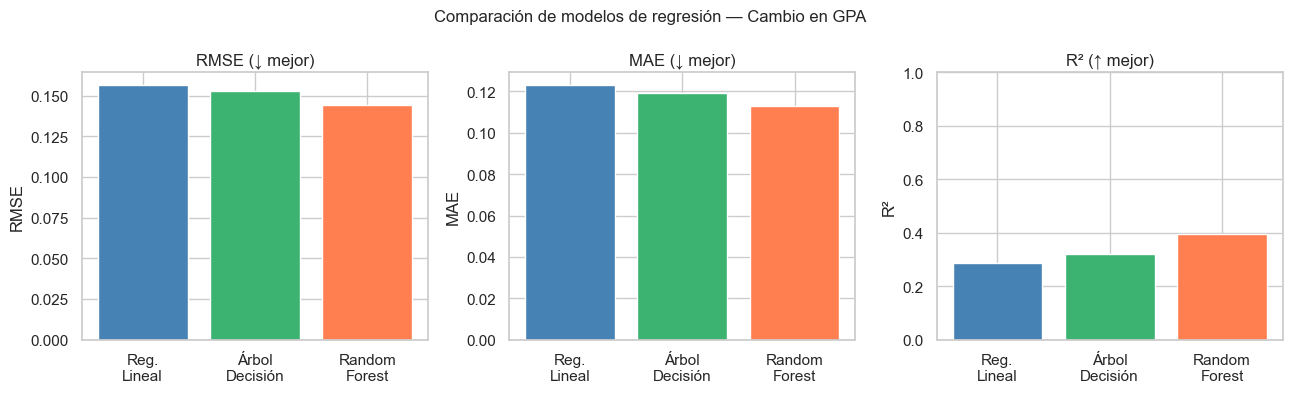

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
modelos_etq = ['Reg.\nLineal', 'Árbol\nDecisión', 'Random\nForest']
colores = ['steelblue', 'mediumseagreen', 'coral']

axes[0].bar(modelos_etq, [rmse_lr, rmse_dt, rmse_rf], color=colores)
axes[0].set_title('RMSE (↓ mejor)')
axes[0].set_ylabel('RMSE')

axes[1].bar(modelos_etq, [mae_lr, mae_dt, mae_rf], color=colores)
axes[1].set_title('MAE (↓ mejor)')
axes[1].set_ylabel('MAE')

axes[2].bar(modelos_etq, [r2_lr, r2_dt, r2_rf], color=colores)
axes[2].set_title('R² (↑ mejor)')
axes[2].set_ylabel('R²')
axes[2].set_ylim(0, 1)

plt.suptitle('Comparación de modelos de regresión — Cambio en GPA', fontsize=12)
plt.tight_layout()
plt.savefig('../reports/14_comparacion_regresion.png', bbox_inches='tight')
plt.show()

Random Forest supera al Árbol de Decisión individual y a la Regresión Lineal en todas las métricas. La Regresión Lineal captura la relación base pero tiene dificultades con las interacciones no lineales entre las variables de uso de IA. El Árbol de Decisión, con profundidad limitada, sacrifica algo de precisión para evitar sobreajuste. Random Forest logra el mejor balance gracias al promedio de múltiples árboles que se complementan entre sí.

### 6. Valores reales vs. predichos — Random Forest

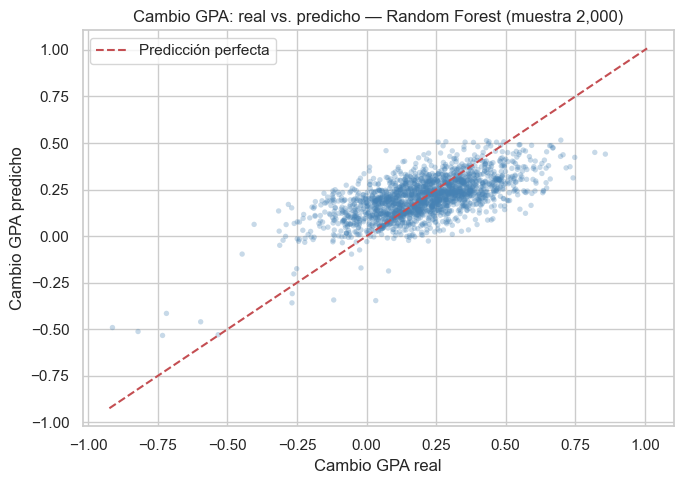

In [10]:
plt.figure(figsize=(7, 5))
# Muestra aleatoria para legibilidad del gráfico
idx = np.random.choice(len(y_test_r), 2000, replace=False)
plt.scatter(y_test_r.iloc[idx], pred_rf_r[idx],
            alpha=0.3, color='steelblue', edgecolors='none', s=15)
lim = [y_test_r.min(), y_test_r.max()]
plt.plot(lim, lim, 'r--', linewidth=1.5, label='Predicción perfecta')
plt.xlabel('Cambio GPA real')
plt.ylabel('Cambio GPA predicho')
plt.title('Cambio GPA: real vs. predicho — Random Forest (muestra 2,000)')
plt.legend()
plt.tight_layout()
plt.savefig('../reports/15_pred_vs_real_regresion.png', bbox_inches='tight')
plt.show()

La dispersión alrededor de la línea diagonal muestra que el modelo captura la tendencia general pero con errores moderados en los casos extremos. Esto es esperable: predecir el cambio exacto en GPA es una tarea difícil porque intervienen factores subjetivos que el dataset no captura (motivación individual, dificultad específica de cada materia, eventos personales del semestre). El modelo es útil para identificar tendencias y grupos de riesgo, no para predicciones individuales exactas.